In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))
from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *

# Imports y configuraciones basicas
import os
import ast
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

# ==========================================
# CONFIGURACIONES GLOBALES
# ==========================================
sns.set_style("whitegrid") 




In [2]:
# 1. CARGA Y LIMPIEZA DE DATOS (Nomenclatura completa)
# ==========================================
pacientes = pd.read_excel("../data/pacientes.xlsx")
hospitales = pd.read_csv("../data/hospitales_coordenadas.csv")

# Diccionarios de referencia para hospitales
dict_complejidad = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))
hospitales['color_rgb'] = hospitales['color'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Asumo que MAPA_FORMAS lo tenés definido antes (ej: MAPA_FORMAS = {'dot': 'o', 'star': '*'})
# hospitales['forma_nodo'] = hospitales['shape'].map(MAPA_FORMAS) 

# --- RECUPERADO: El renombre COMPLETO de columnas ---
pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',

    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',

    'Sexo': 'sexo',
    'Edad': 'edad',

    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',

    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',

    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',

    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',

    'Asistencia Respiratoria Mecánica': 'requiere_arm',

    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',

    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',

    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})

pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')
pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================
# 2. MÉTRICAS DE TRAYECTORIA DEL PACIENTE (RED)
# ==========================================
# Agrupamos por paciente para extraer el inicio, fin y los motivos
trayectorias_metricas = pacientes.groupby('paciente_id').agg(
    fecha_ingreso_red=('fecha_ingreso', 'first'),  
    fecha_egreso_red=('fecha_egreso', 'last'),     
    motivos_historial=('motivo_egreso', list),     
    motivo_fin_caso=('motivo_egreso', 'last')      
).reset_index()

# Validamos que el motivo de fin de caso
condiciones = [
    trayectorias_metricas['motivo_fin_caso'] == 'alta-domiciliaria',
    trayectorias_metricas['motivo_fin_caso'] == 'muerte',
    trayectorias_metricas['motivo_fin_caso'] == 'traslado-otro',
    trayectorias_metricas['motivo_fin_caso'] == 'traslado-extra-sanitario'
]
resultados = ['alta', 'muerte', 'hospital externo', 'alta hotel']

trayectorias_metricas['motivo_fin_caso'] = np.select(condiciones, resultados, default='otro/desconocido')
pacientes = pacientes.merge(trayectorias_metricas, on='paciente_id', how='left')


# ==========================================
# 3. CORE DEL MODELO: CONSTRUCCIÓN DE TRASLADOS
# ==========================================
pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)
pacientes['estado_destino'] = pacientes.groupby('paciente_id')['estado_ingreso'].shift(-1)
pacientes['tipo_destino'] = pacientes.groupby('paciente_id')['tipo_ingreso'].shift(-1) 

pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0

motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']
mask_traslados = (
    pacientes['hospital_destino'].notna() & 
    pacientes['motivo_egreso'].isin(motivos_validos) & 
    (pacientes['hospital_origen'] != pacientes['hospital_destino'])
)

df_potenciales = pacientes[mask_traslados].copy() 
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})

df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 3
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)

# ==========================================
# 4. DF DE TRAYECTORIAS (Reconstrucción completa recuperada)
# ==========================================
mapa_estados = {
    'criticas': 3,
    'intermedias': 2,
    'generales': 1
}


# Generamos el DF final de trayectorias
df_trayectorias_final = df_traslados.groupby('paciente_id').apply(armar_trayectoria, dict_complejidad=dict_complejidad).reset_index()

# ==========================================
# 5. PREPARACIÓN DE COORDENADAS (Unificado)
# ==========================================
df_coordenadas = hospitales.rename(columns={'Nombre Hospital': 'hospital', 'Latitud': 'lat', 'Longitud': 'lon'})

# Ajustes manuales unificados (valores finales)
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.03

# Desplazar duplicados
nuevas_filas = []
for (lat, lon), group in df_coordenadas.groupby(['lat', 'lon']):
    for i, (_, row) in enumerate(group.iterrows()):
        row_mod = row.copy()
        if i > 0:
            row_mod['lon'] = lon + 0.01   
            row_mod['lat'] = lat + (i * 0.015)  
        nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)
hospitales_conocidos = set(df_coordenadas['hospital'])

In [3]:
# Funciones de visualizacion
###########################################

    


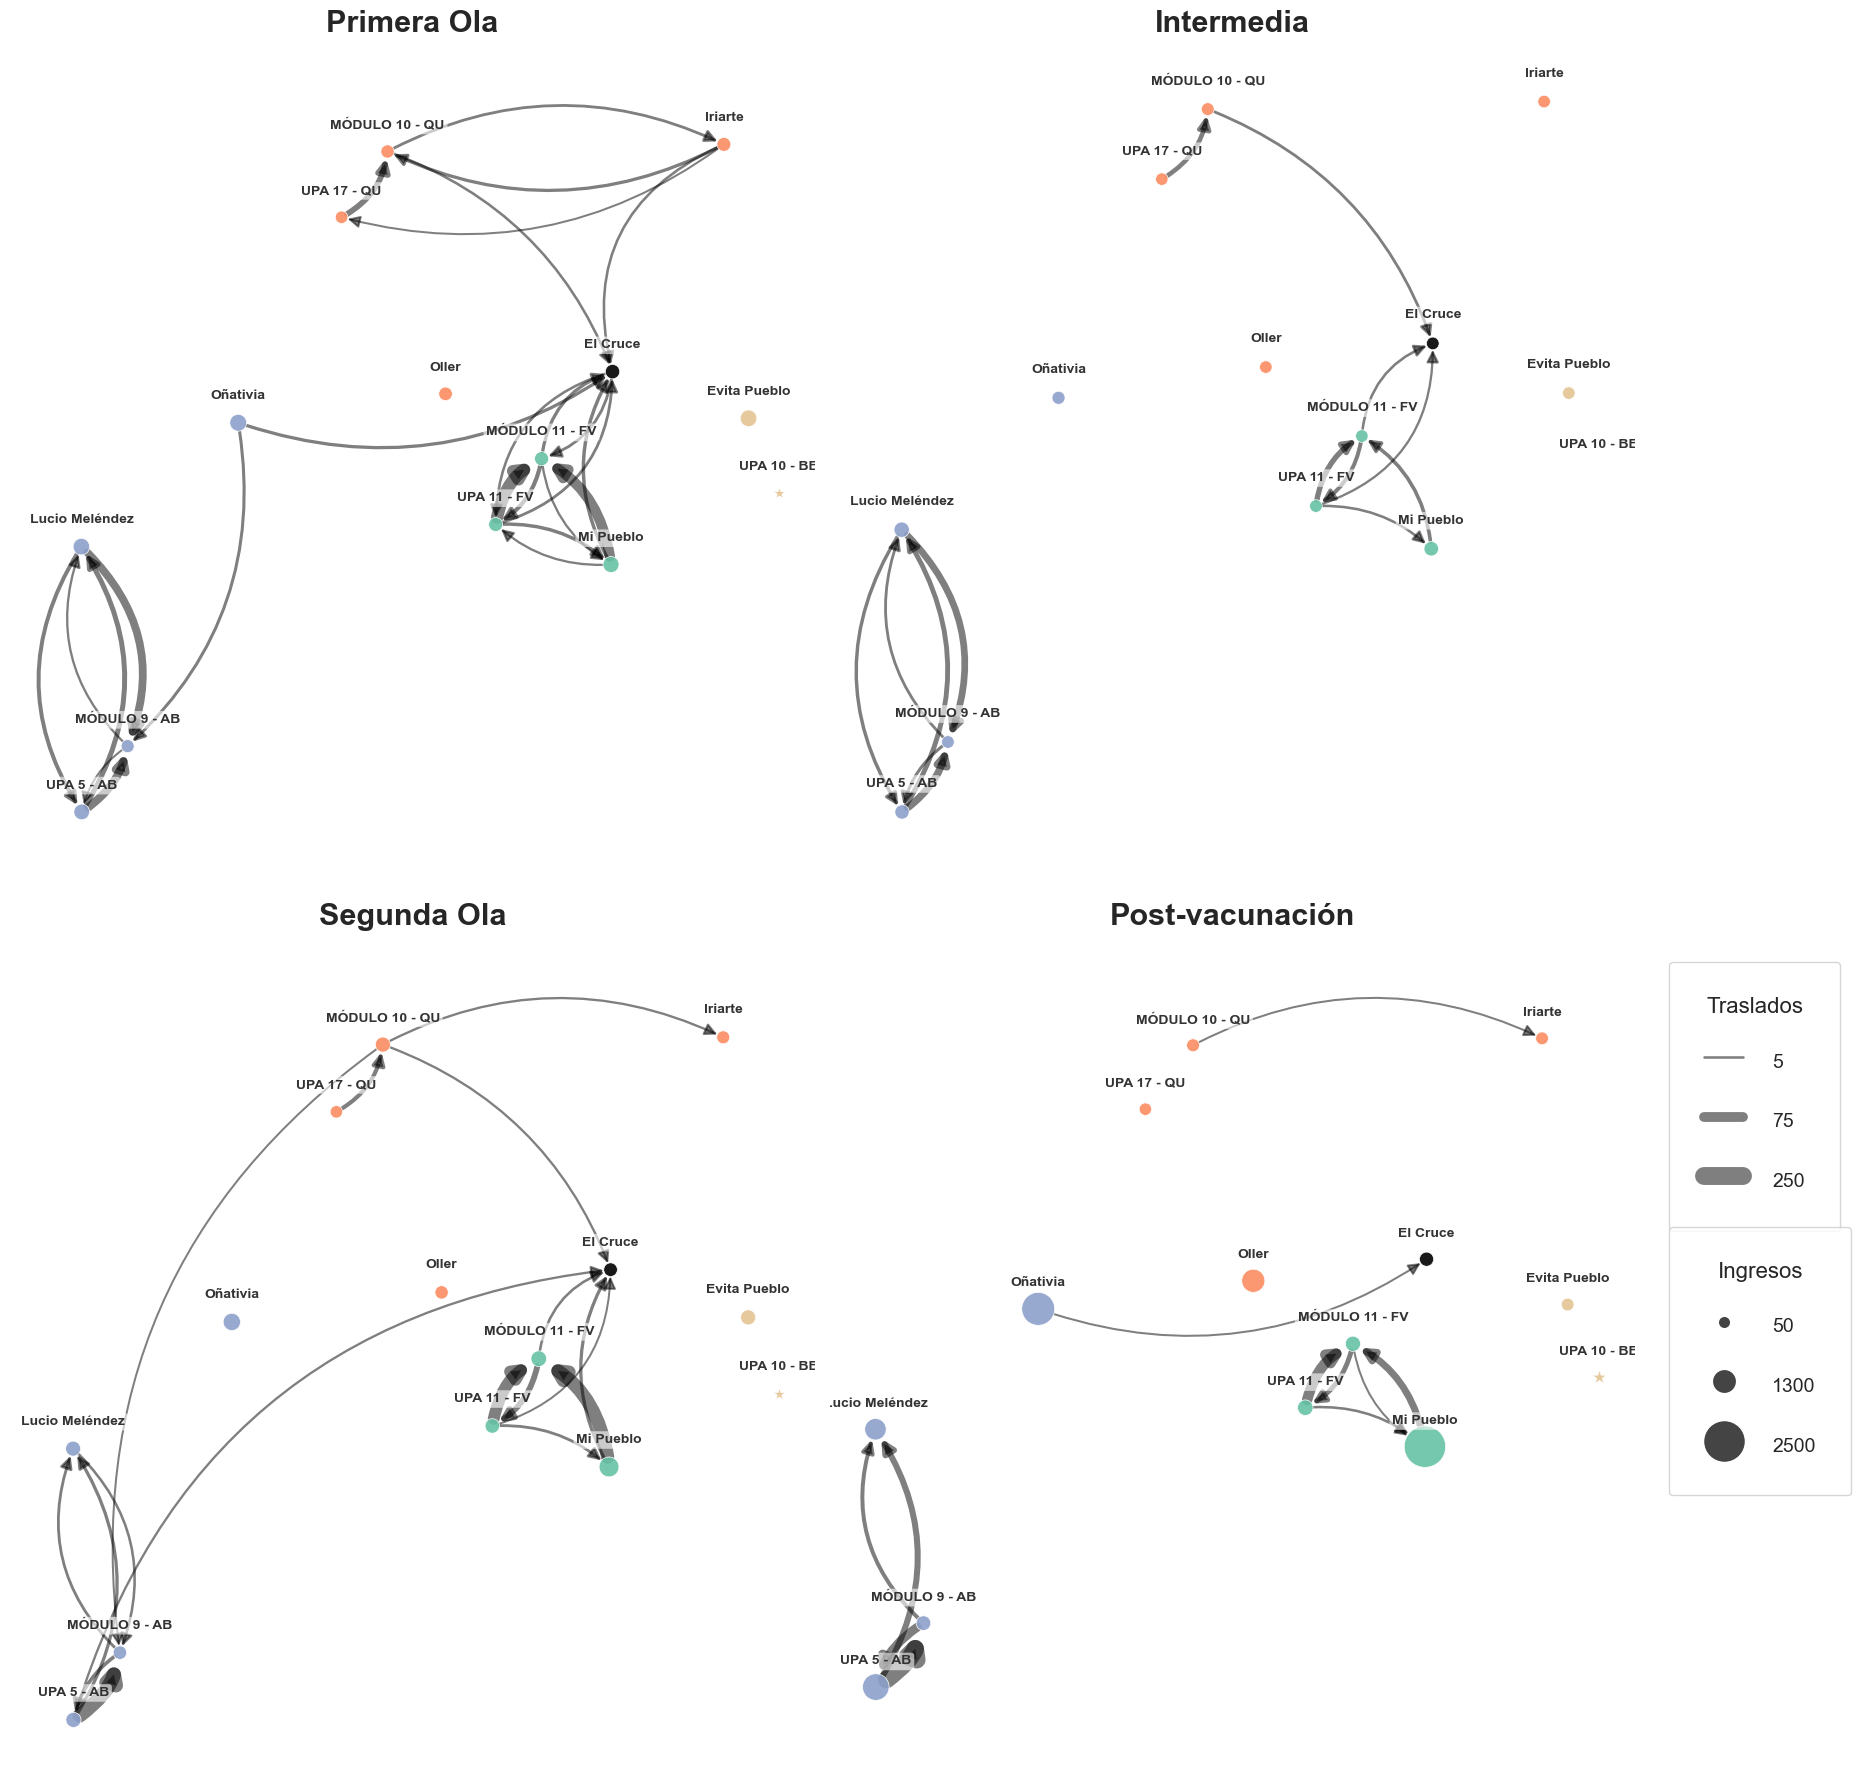

In [4]:
# GRÁFICO 1: GRILLA 2x2 PERIODOS
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.patch.set_facecolor('white')

cfg_grilla = {
    'min_grosor': 0.05, 'max_grosor': 18.0, 'min_tamano': 80, 'max_tamano': 3000, 
    'escala_nodo': 'cuadratica', 'color_por_origen': False, 'aristas_negras': True,
    'alpha_arista': 0.5, 'arrow_size': 18, 'forzar_i_min_50': True,
    'leg_title_sz': 16, 'leg_lbl_sz': 14, 'leg_dynamic_spc': True, 'lbl_size': 10,
    'lbl_weight': 'bold',
    'lbl_offset': 0.006,    # Subimos este valor si el nombre pisa el nodo
    'lbl_bbox': True,       # Activamos el fondo
    'lbl_bbox_alpha': 0.6,  # Transparencia del fondo blanco
    'lbl_color': '#333333'
}

# Filtro global previo para que el máximo sea real
mask_val_g = (df_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & \
             (df_traslados['hospital_destino'].isin(hospitales_conocidos)) & \
             (df_traslados['hospital_ingreso'] != df_traslados['hospital_destino'])

max_tras_glob = df_traslados[mask_val_g].groupby(['hospital_ingreso', 'hospital_destino']).size().max()
max_ing_glob = pacientes[pacientes['hospital_origen'].isin(hospitales_conocidos)]['hospital_origen'].value_counts().max()
v_max_enc, i_max_enc = 0, 0

for idx, (titulo, inicio, fin) in enumerate(PERIODOS):
    ax = axes.flatten()[idx]
    ax.set_title(titulo, fontsize=22, fontweight='bold', pad=20)
    
    # Filtrado estricto por periodo
    df_p_per = pacientes[pacientes['fecha_ingreso'].between(inicio, fin)]
    df_t_per = df_traslados[df_traslados['fecha_egreso'].between(inicio, fin)]
    
    ingresos_ser = df_p_per['hospital_origen'].value_counts()
    
    mask_val_per = (df_t_per['hospital_ingreso'].isin(hospitales_conocidos)) & \
                   (df_t_per['hospital_destino'].isin(hospitales_conocidos)) & \
                   (df_t_per['hospital_ingreso'] != df_t_per['hospital_destino'])
                   
    traslados_ser = df_t_per[mask_val_per].groupby(['hospital_ingreso', 'hospital_destino']).size()
    traslados_dib = traslados_ser[traslados_ser > 2].reset_index(name='peso')
    
    if not traslados_dib.empty: v_max_enc = max(v_max_enc, traslados_dib['peso'].max())
    if not ingresos_ser.empty: i_max_enc = max(i_max_enc, ingresos_ser.max())

    G = nx.DiGraph()
    for _, row in df_coordenadas.iterrows():
        n_ing = ingresos_ser.get(row['hospital'], 0)
        sz = aplicar_escala_visual(n_ing, max_ing_glob, cfg_grilla['min_tamano'], cfg_grilla['max_tamano'], cfg_grilla['escala_nodo'])
        G.add_node(row['hospital'], pos=(row['lon'], row['lat']), color=row.get('color_rgb', 'grey'), size=sz, shape=MAPA_FORMAS.get(row['shape'], 'o'), alpha=0.9 if n_ing > 0 else 0.4)
    
    for _, row_t in traslados_dib.iterrows():
        G.add_edge(row_t['hospital_ingreso'], row_t['hospital_destino'], weight=row_t['peso'])

    dibujar_grafo_nx(ax, G, nx.get_node_attributes(G, 'pos'), max_tras_glob, max_ing_glob, cfg_grilla)

generar_leyendas(axes.flatten()[-1], v_max_enc, 50, i_max_enc, max_tras_glob, max_ing_glob, cfg_grilla, [(1.03, 1.0), None, (1.03, 0.68)])
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


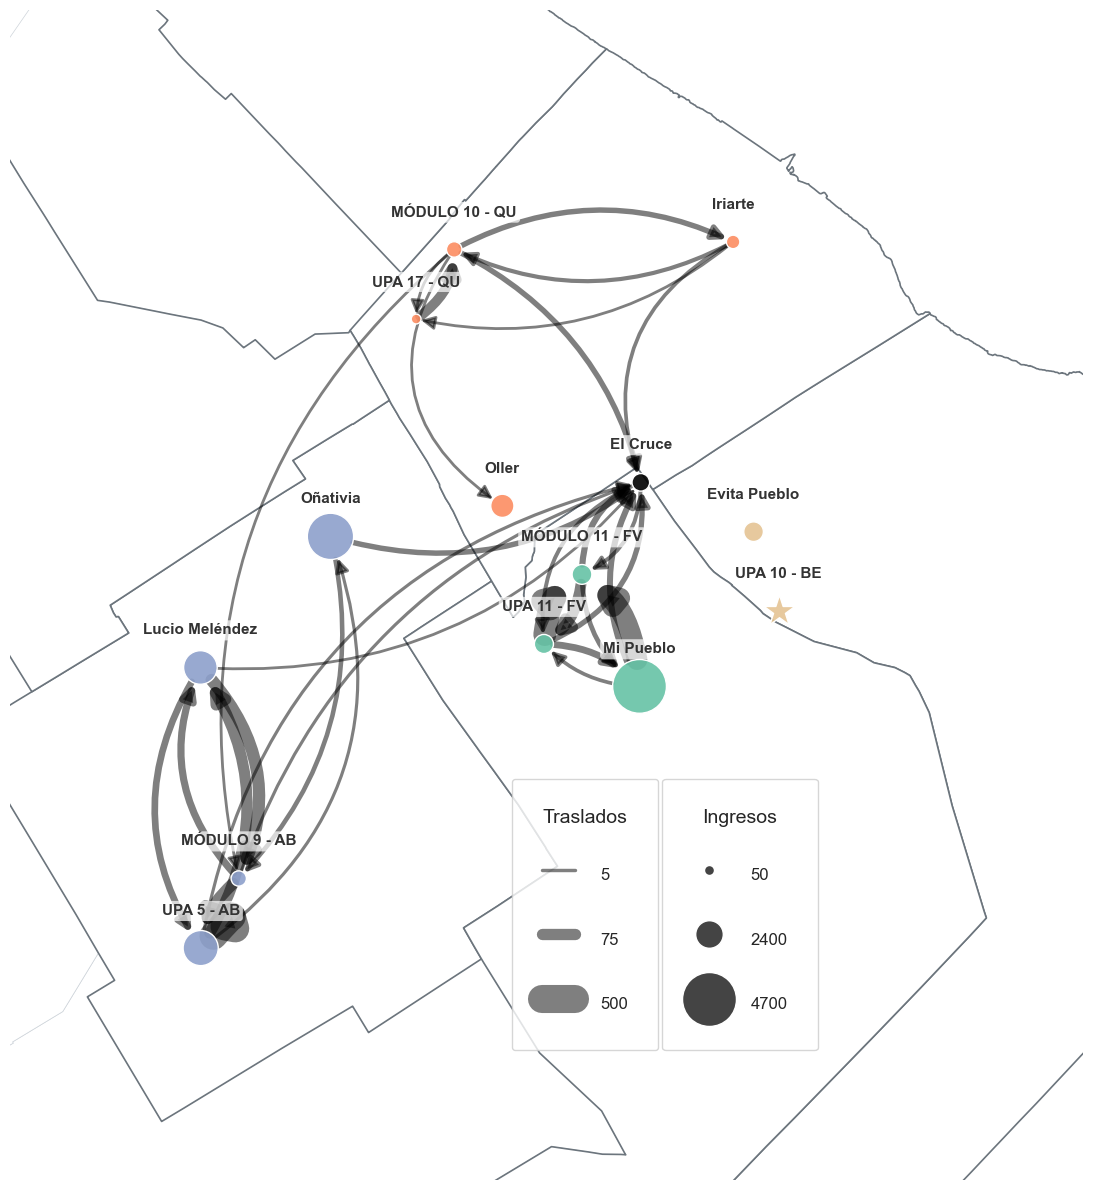

In [5]:
# GRÁFICO 2: MAPA GEOPANDAS
# ==========================================
fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('white')

ingresos_globales = pacientes[pacientes['hospital_origen'].isin(hospitales_conocidos)]['hospital_origen'].value_counts()
min_i_g = ingresos_globales.min() if not ingresos_globales.empty else 0

cfg_geo = {
    'min_grosor': 0.5, 'max_grosor': 20.0, 'min_tamano': 50, 'max_tamano': 1500,
    'escala_nodo': 'cuadratica', 'color_por_origen': False, 'alpha_arista': 0.5, 'aristas_negras': True,
    'arrow_size': 20, 'node_size_edge': 600, 'lbl_offset': 0.008, 'lbl_size': 11,
    'lbl_weight': 'bold', 'lbl_color': '#333333', 'lbl_bbox': True, 'zorder_nodos': 5, 
    'zorder_aristas': 6, 'lw_nodos': 1.0, 'forzar_i_min_50': True, 'min_ingresos_real': min_i_g,
    'leg_title_sz': 14, 'leg_lbl_sz': 12, 'leg_dynamic_spc': True,
    'lbl_bbox_alpha': 0.7,
}

deptos = gpd.read_file("../data/shapefiles/departamento/departamentoPolygon.shp")
pba = deptos[deptos["in1"].astype(str).str.startswith("06")].to_crs(epsg=4326)
sudeste = pba[pba["nam"].astype(str).str.upper().isin(["QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA", "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA", "AVELLANEDA", "MORON", "ITUZAINGO"])]

pba.plot(ax=ax, color="#FFFFFF", edgecolor="#ced4da", linewidth=0.5, zorder=0)
sudeste.plot(ax=ax, color="#FFFFFF", edgecolor="#6c757d", linewidth=1.2, zorder=1)

# Filtro estricto previo
mask_val_geo = (df_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & \
               (df_traslados['hospital_destino'].isin(hospitales_conocidos)) & \
               (df_traslados['hospital_ingreso'] != df_traslados['hospital_destino'])

tras_grp = df_traslados[mask_val_geo].groupby(['hospital_ingreso', 'hospital_destino']).size()
tras_dib = tras_grp[tras_grp > 2]

max_i_g = ingresos_globales.max()
max_t_g = tras_dib.max() if not tras_dib.empty else 1

G_geo = nx.DiGraph()
for _, row in df_coordenadas.iterrows():
    cant = ingresos_globales.get(row['hospital'], 0)
    sz = aplicar_escala_visual(cant, max_i_g, cfg_geo['min_tamano'], cfg_geo['max_tamano'], 'cuadratica', min_valor=cfg_geo['min_ingresos_real'])
    G_geo.add_node(row['hospital'], pos=(row['lon'], row['lat']), color=row.get('color_rgb', 'grey'), size=sz, shape=MAPA_FORMAS.get(row['shape'], 'o'), alpha=0.9 if cant > 0 else 0.4)

for (u, v), peso in tras_dib.items():
    G_geo.add_edge(u, v, weight=peso)

dibujar_grafo_nx(ax, G_geo, nx.get_node_attributes(G_geo, 'pos'), max_t_g, max_i_g, cfg_geo)

ax.set_xlim(df_coordenadas['lon'].min() - 0.05, df_coordenadas['lon'].max() + 0.08)
ax.set_ylim(df_coordenadas['lat'].min() - 0.05, df_coordenadas['lat'].max() + 0.05)


generar_leyendas(ax, max_t_g, min_i_g, max_i_g, max_t_g, max_i_g, cfg_geo, [(0.46, 0.35), None, (0.60, 0.35)])

plt.tight_layout()
plt.show()

In [6]:
# FUNCIONES AUXILIARES DE ESTADÍSTICA
# ==========================================


,Primera Ola,Intermedia,Segunda Ola,Post-vacunación
Días totales,153,120,153,518
Admisiones (Prom. diario),5944 (38.8),2839 (23.7),6193 (40.5),11347 (21.9)
Pacientes admitidos,5363,2558,5474,10601
Traslados totales (% admisiones),467 (7.9%),196 (6.9%),509 (8.2%),494 (4.4%)
Pacientes trasladados,438,176,490,438
Promedio diario de traslados,3.1,1.6,3.3,1.0
Traslados en ambulancia (% total),258 (55.2%),98 (50.0%),194 (38.1%),91 (18.4%)
Traslados UPA-Módulos,270,142,358,454
Rutas UPA-Módulos,13,11,14,9
Rutas totales | Ambulancia,25 | 20,14 | 9,17 | 12,11 | 7


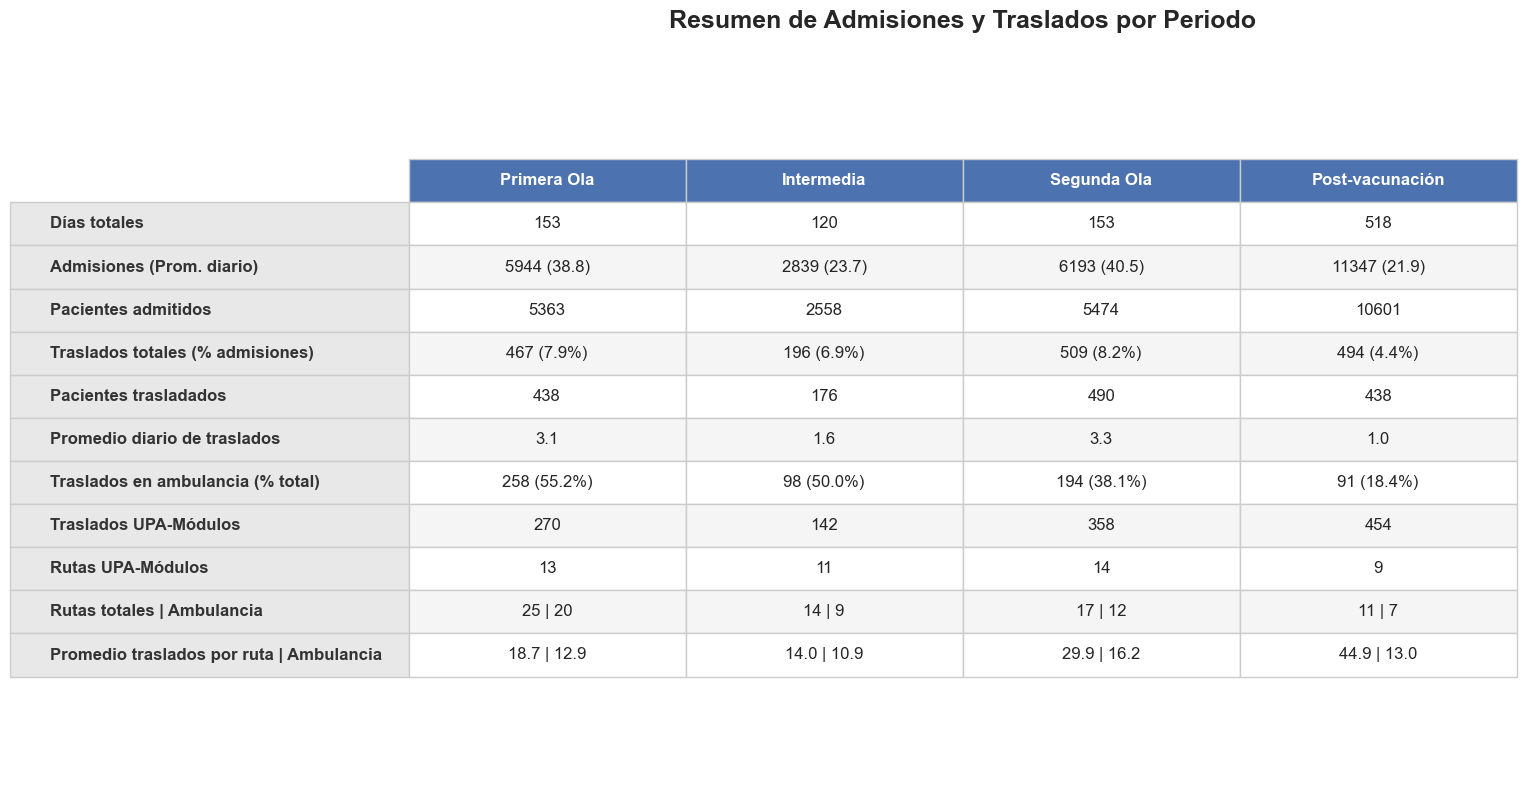

In [7]:
# 7. GENERACIÓN DE TABLA RESUMEN (MÉTRICAS)
# ==========================================



df_traslados['es_ambulancia'] = df_traslados.apply(requiere_ambulancia, axis=1)



# EJECUCIÓN SECCIÓN 7
tabla_resumen = generar_tabla_resumen(pacientes, df_traslados, PERIODOS, hospitales_conocidos)
display(tabla_resumen)
exportar_tabla_estetica(tabla_resumen)


c:\Users\micag\Documents\RedesHospitales\src\funciones_complejas.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


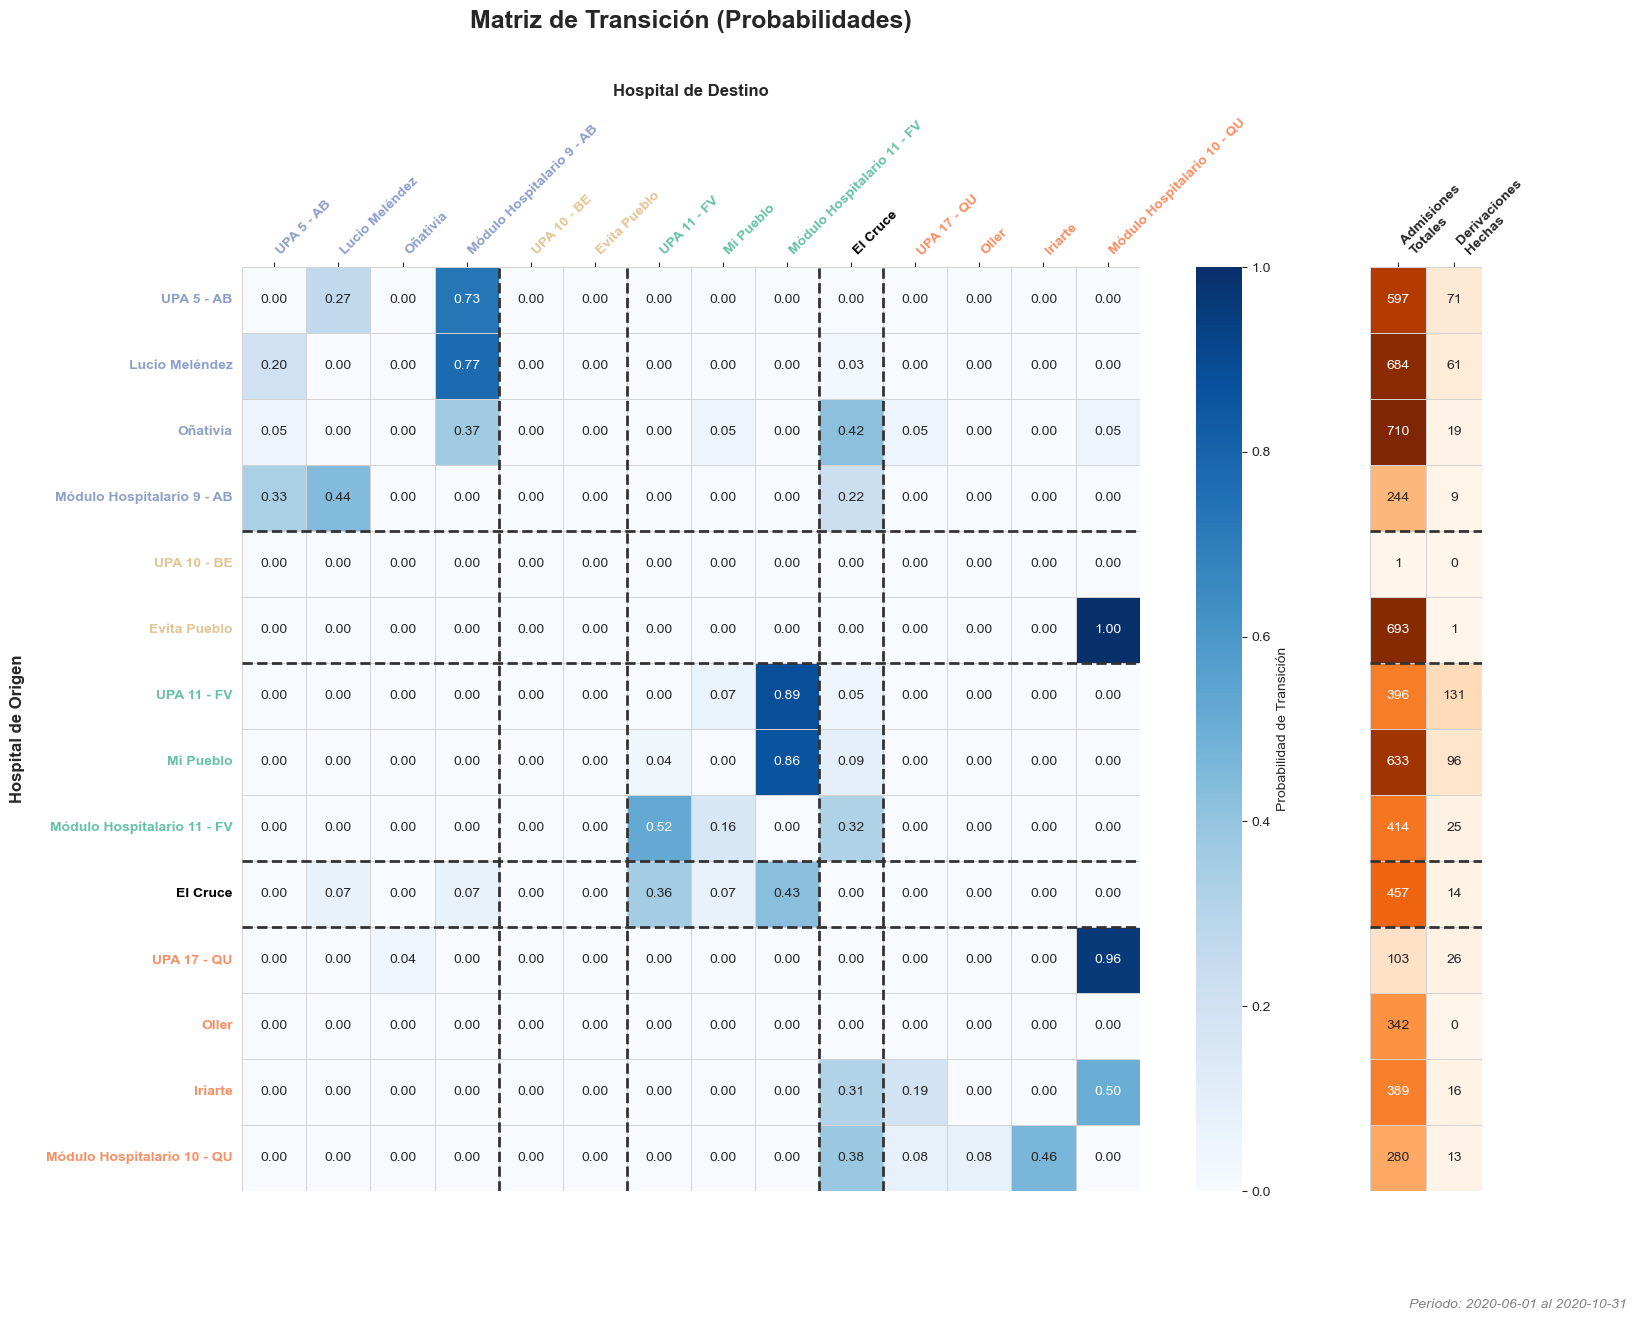

c:\Users\micag\Documents\RedesHospitales\src\funciones_complejas.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


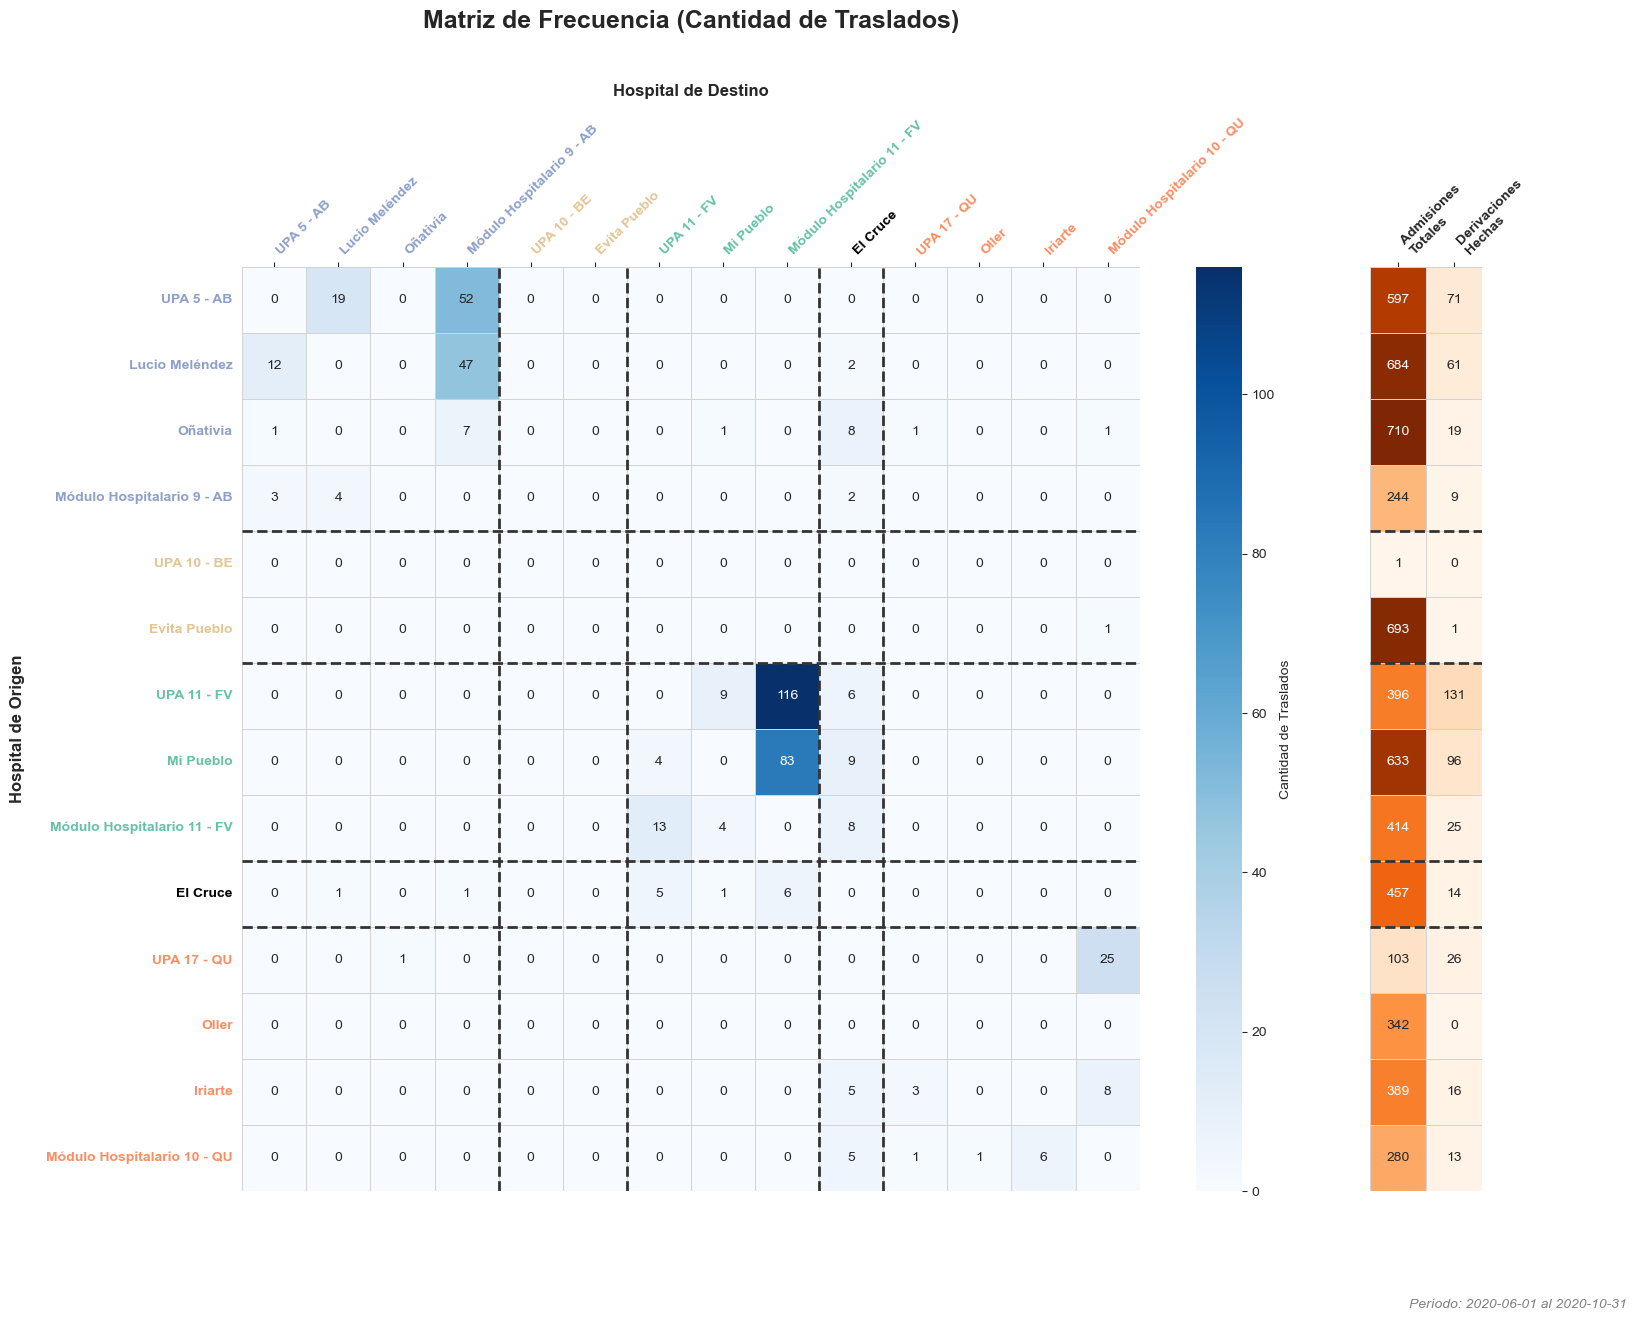

In [8]:
# 8. GENERACIÓN DE MATRICES
# ==============================================================================

# EJECUCIÓN SECCIÓN 8
ini_estudio, fin_estudio = PERIODOS[0][1], PERIODOS[0][2]
generar_matrices_traslados(df_traslados, pacientes, hospitales, ini_estudio, fin_estudio, 'probabilidad')
generar_matrices_traslados(df_traslados, pacientes, hospitales, ini_estudio, fin_estudio, 'cantidad')

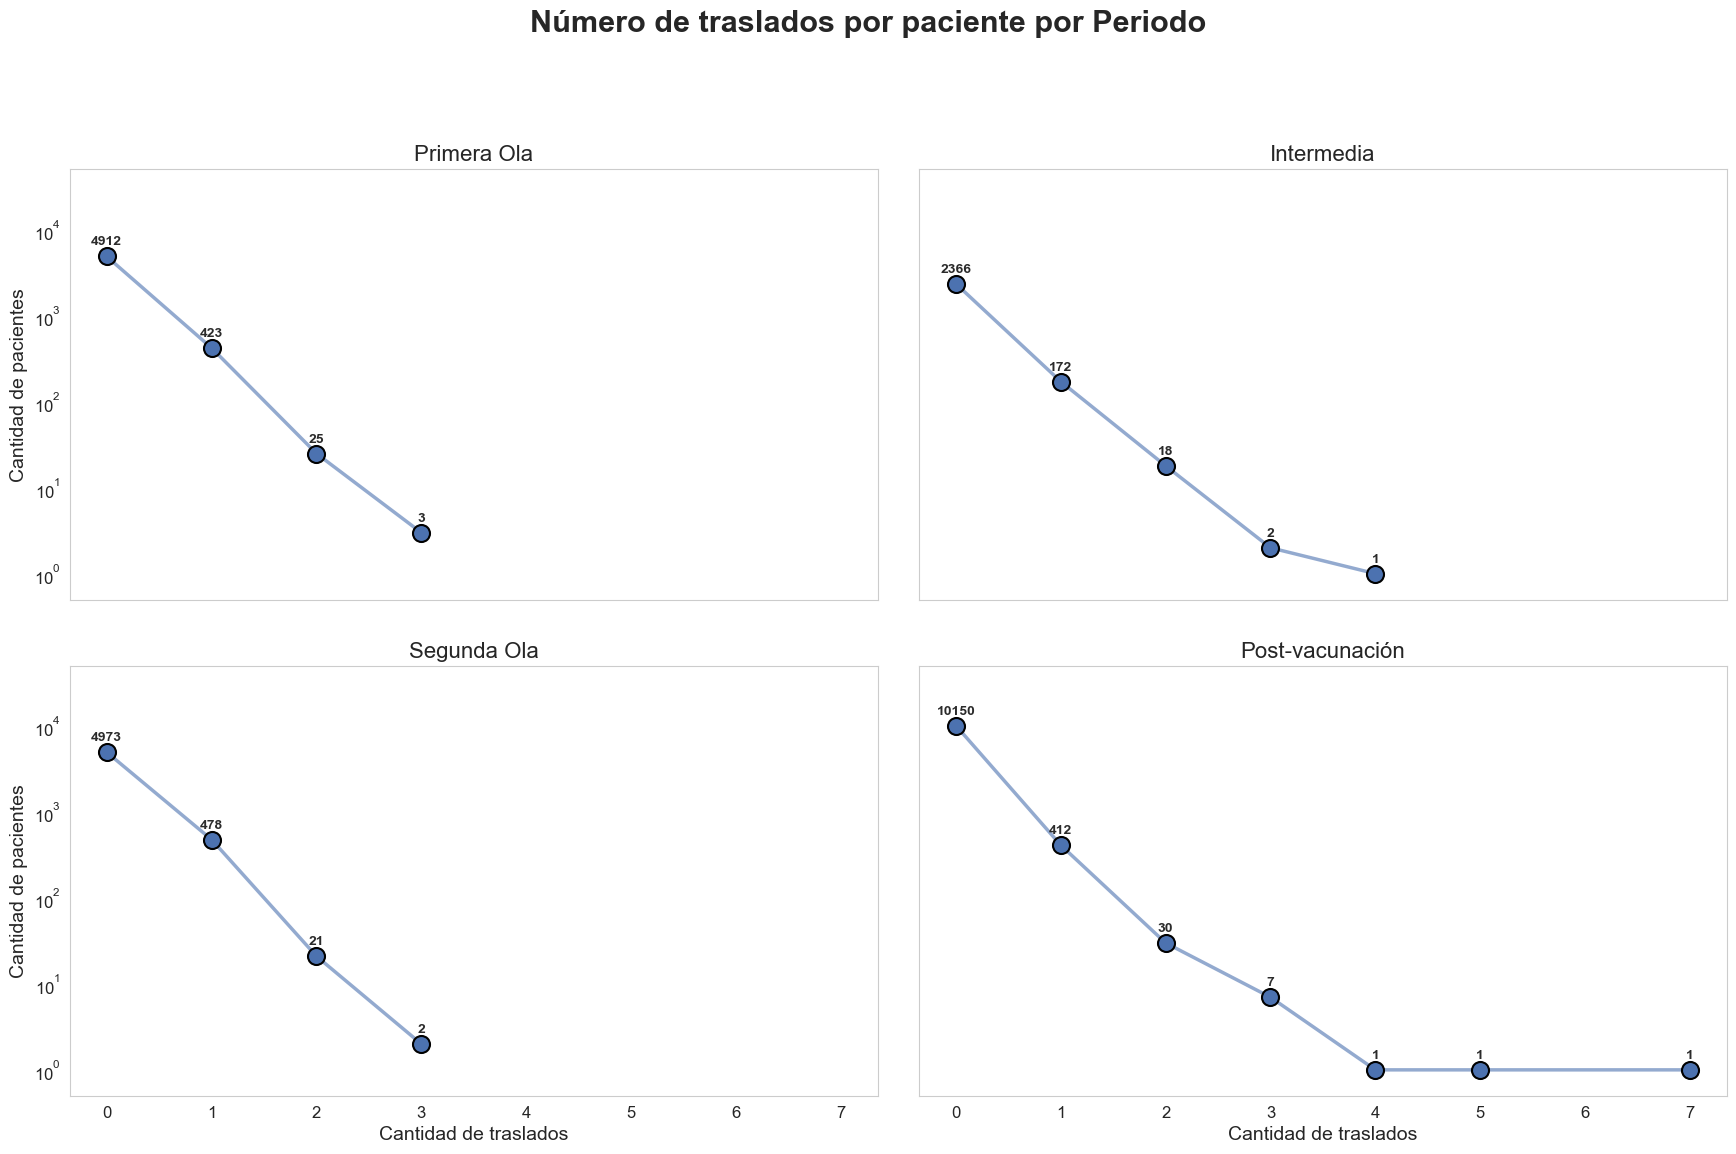

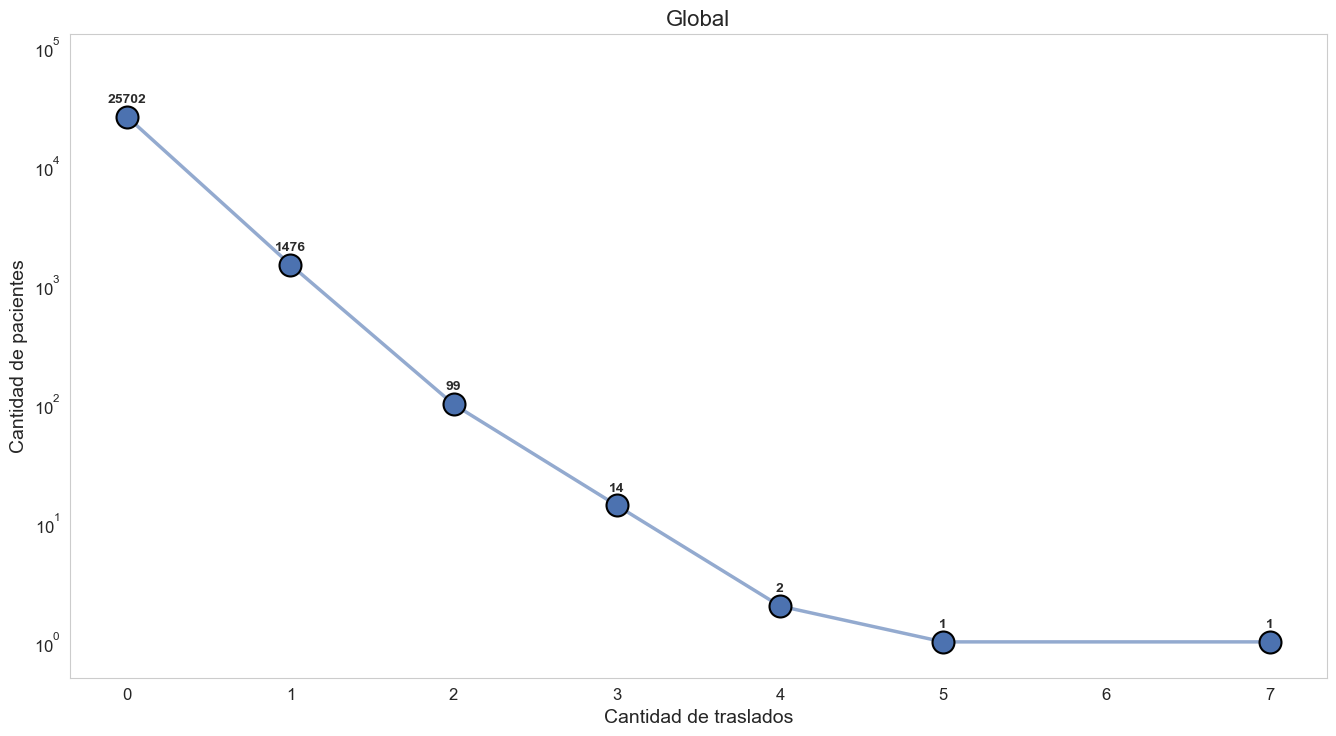

--------------------------------------------------
PROMEDIO DE TRASLADOS POR PACIENTE (INCLUYE 0s):
Primera Ola: 0.0899
Intermedia: 0.0852
Segunda Ola: 0.0961
Post-vacunación: 0.0480
Global: 0.0636
--------------------------------------------------


c:\Users\micag\Documents\RedesHospitales\src\visualizacion.py:465: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.96 if not es_global else 1], pad=3.0)


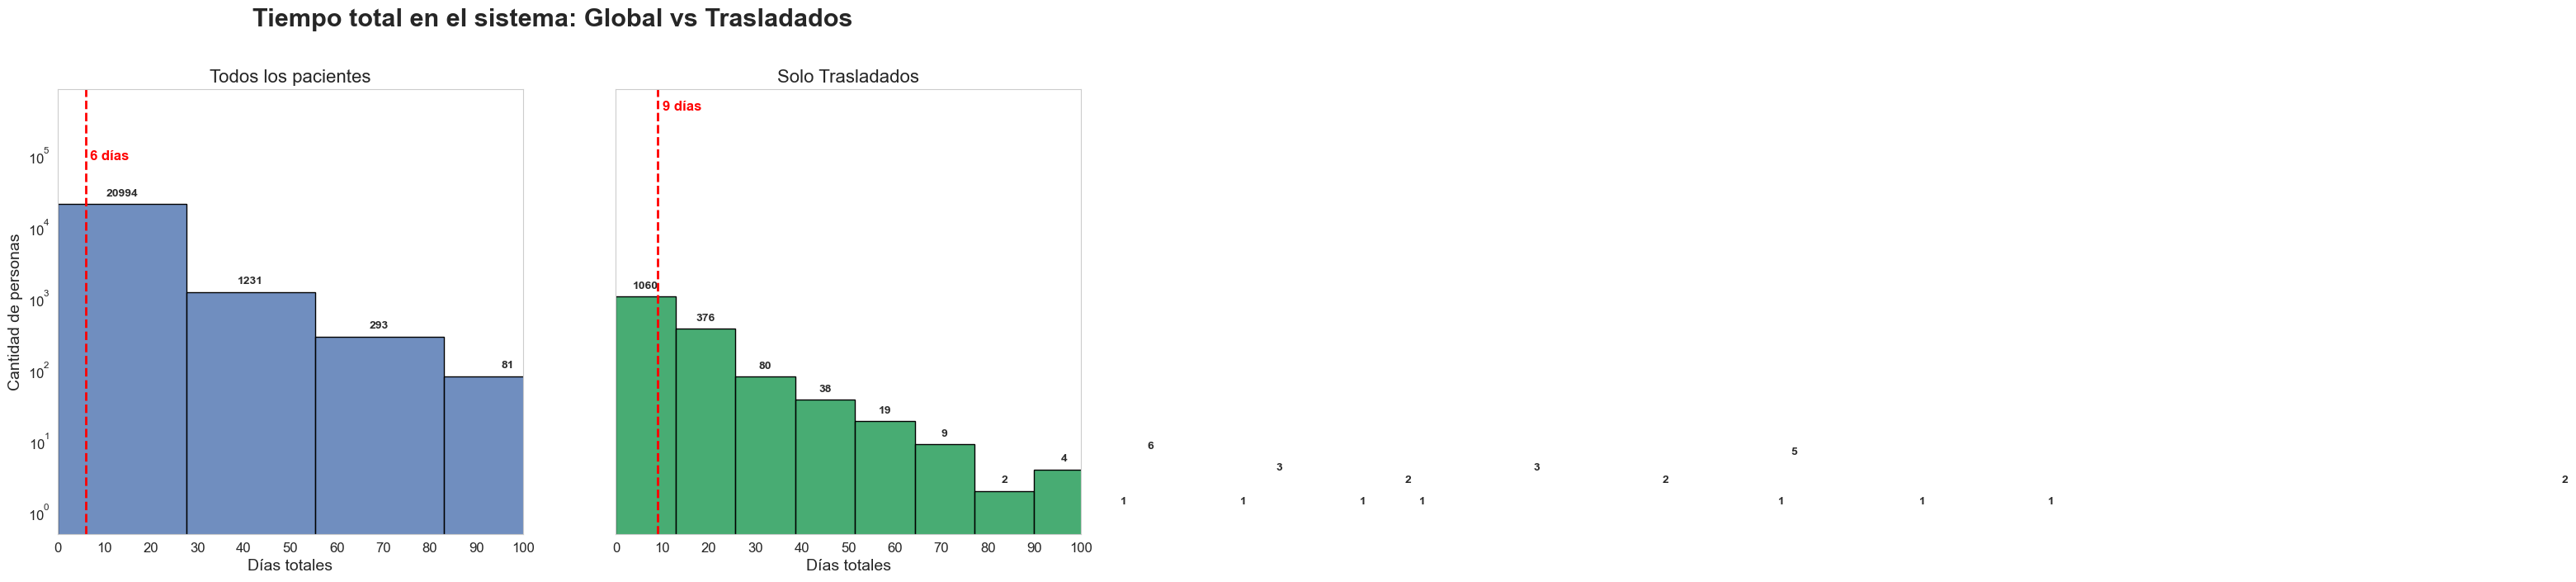

c:\Users\micag\Documents\RedesHospitales\src\visualizacion.py:465: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.96 if not es_global else 1], pad=3.0)


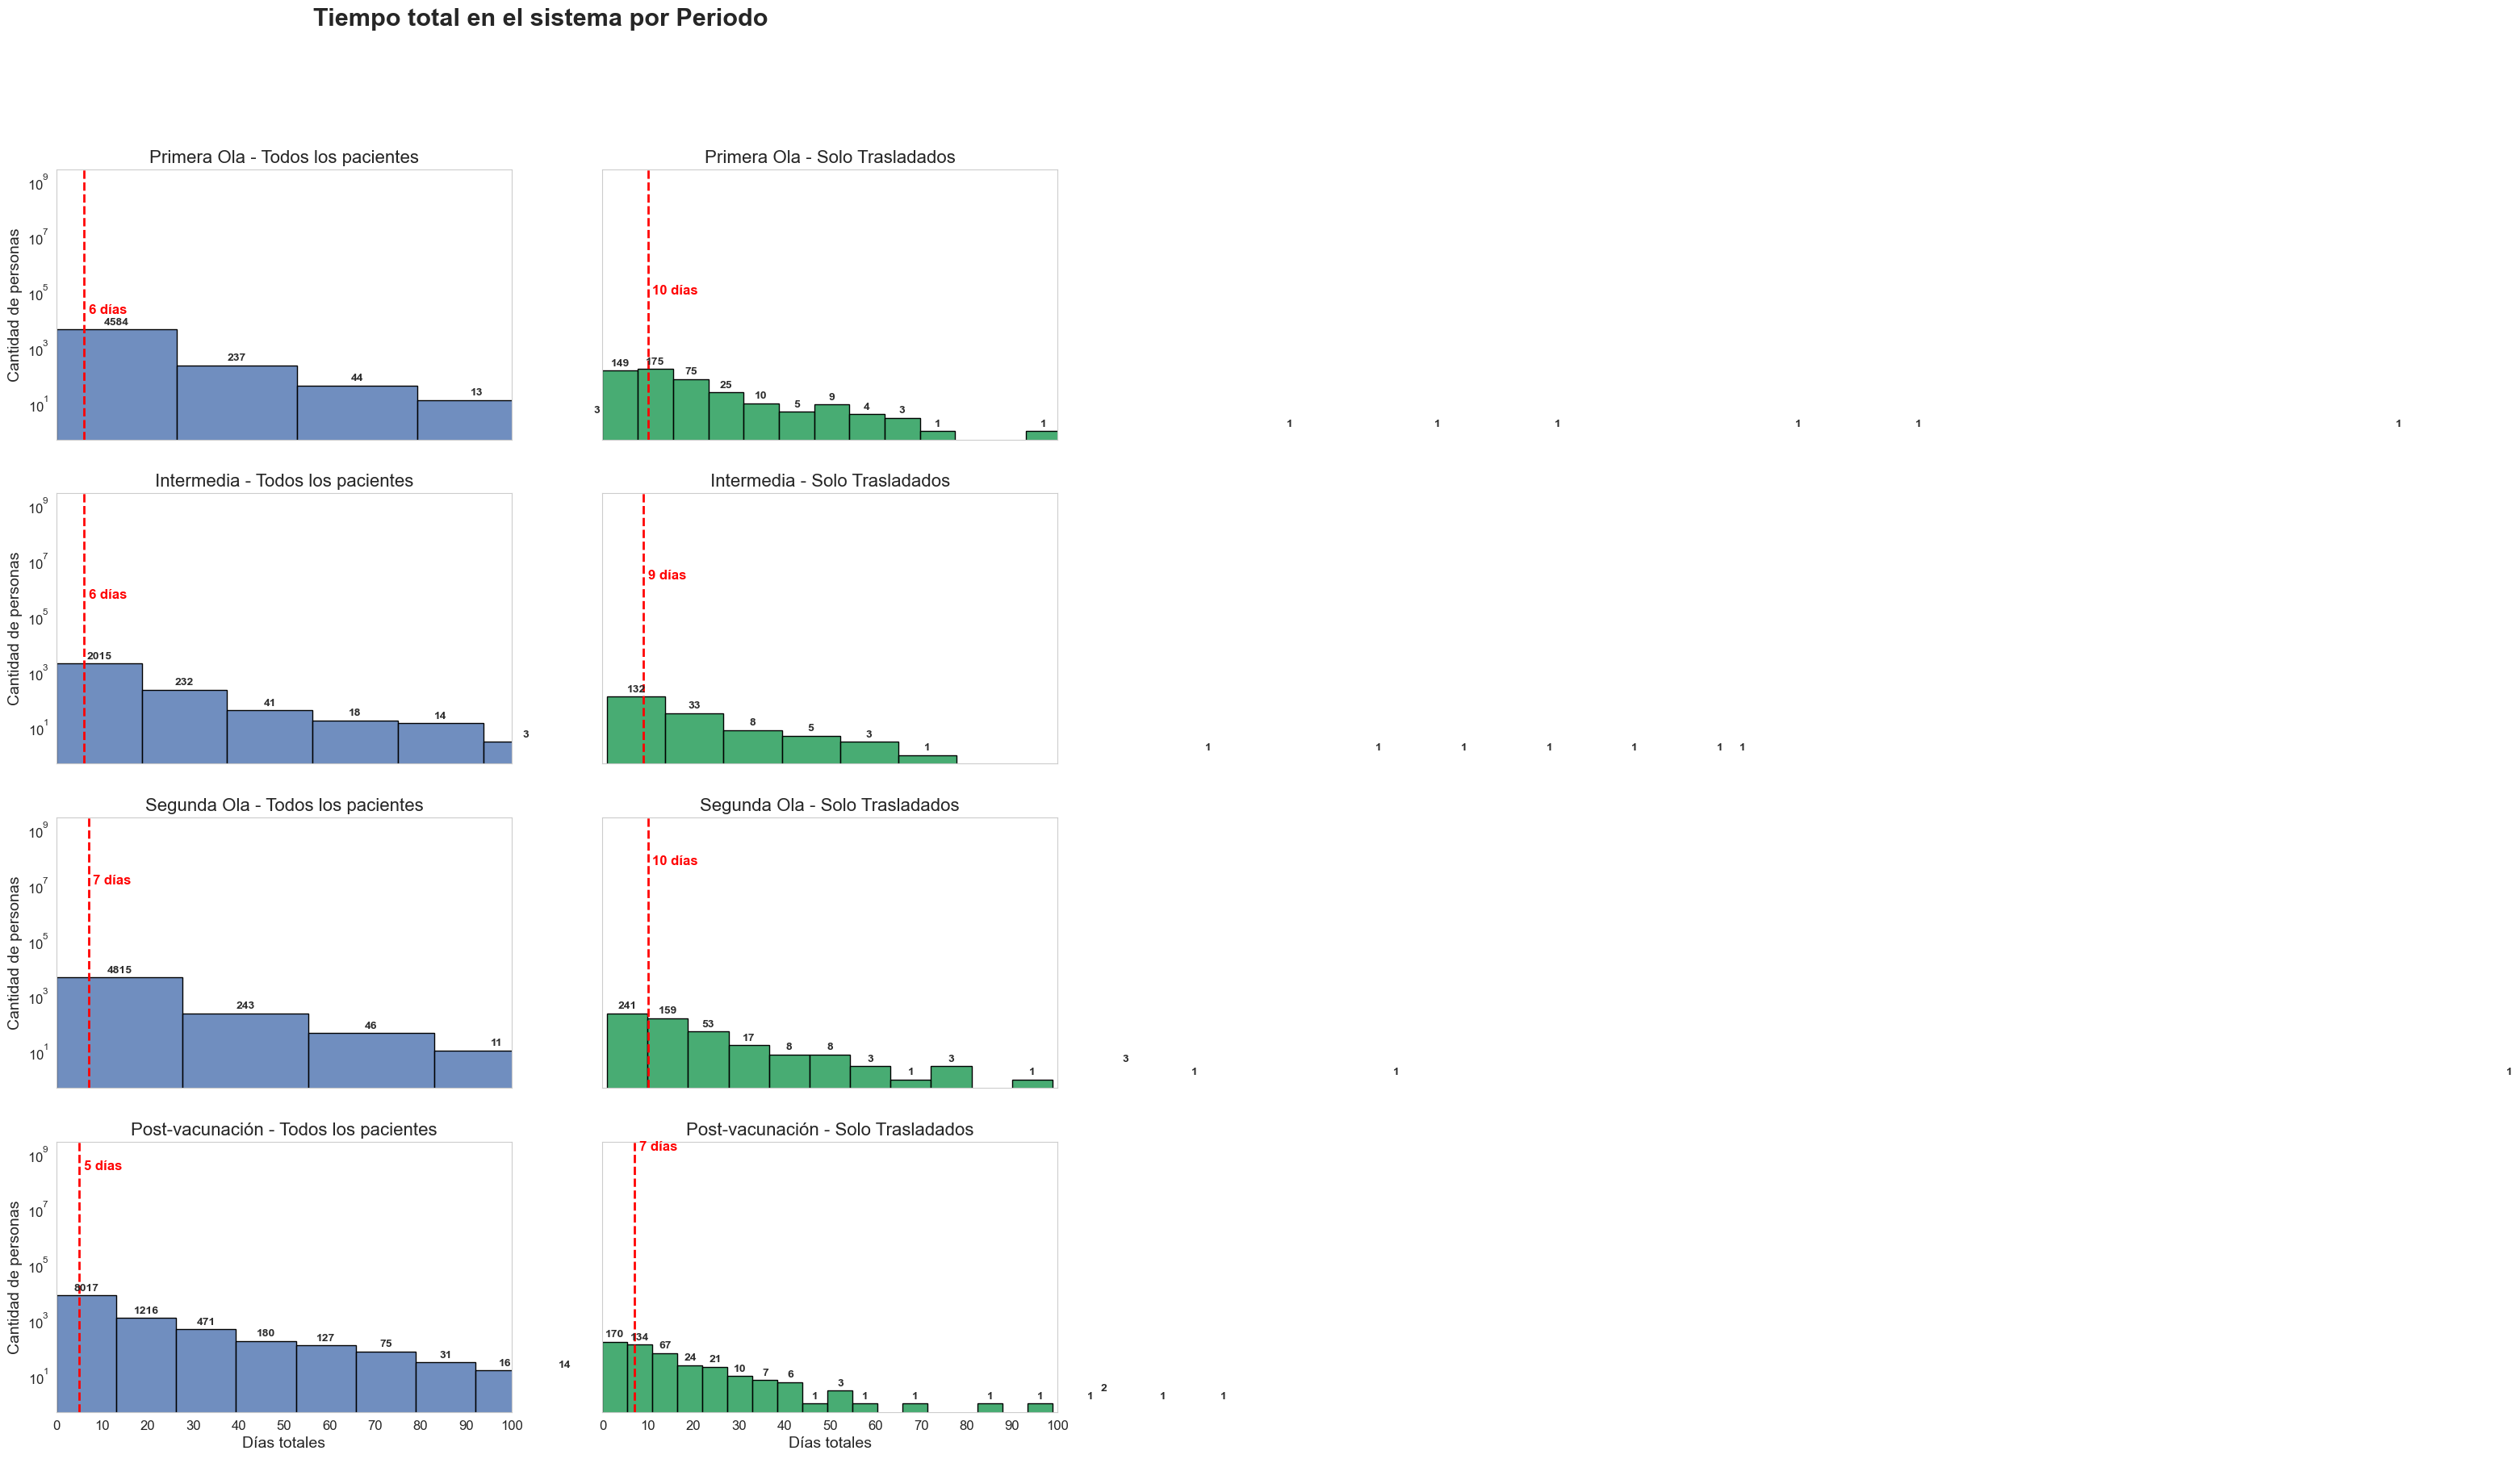

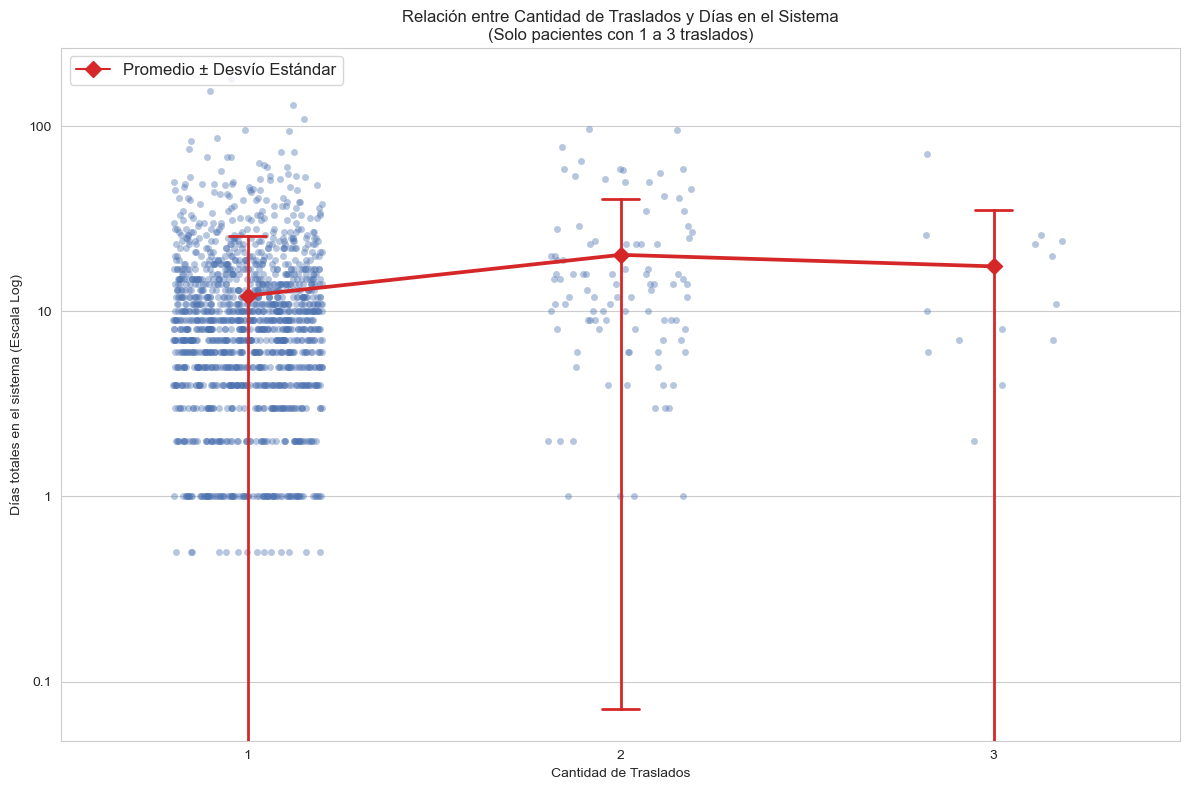

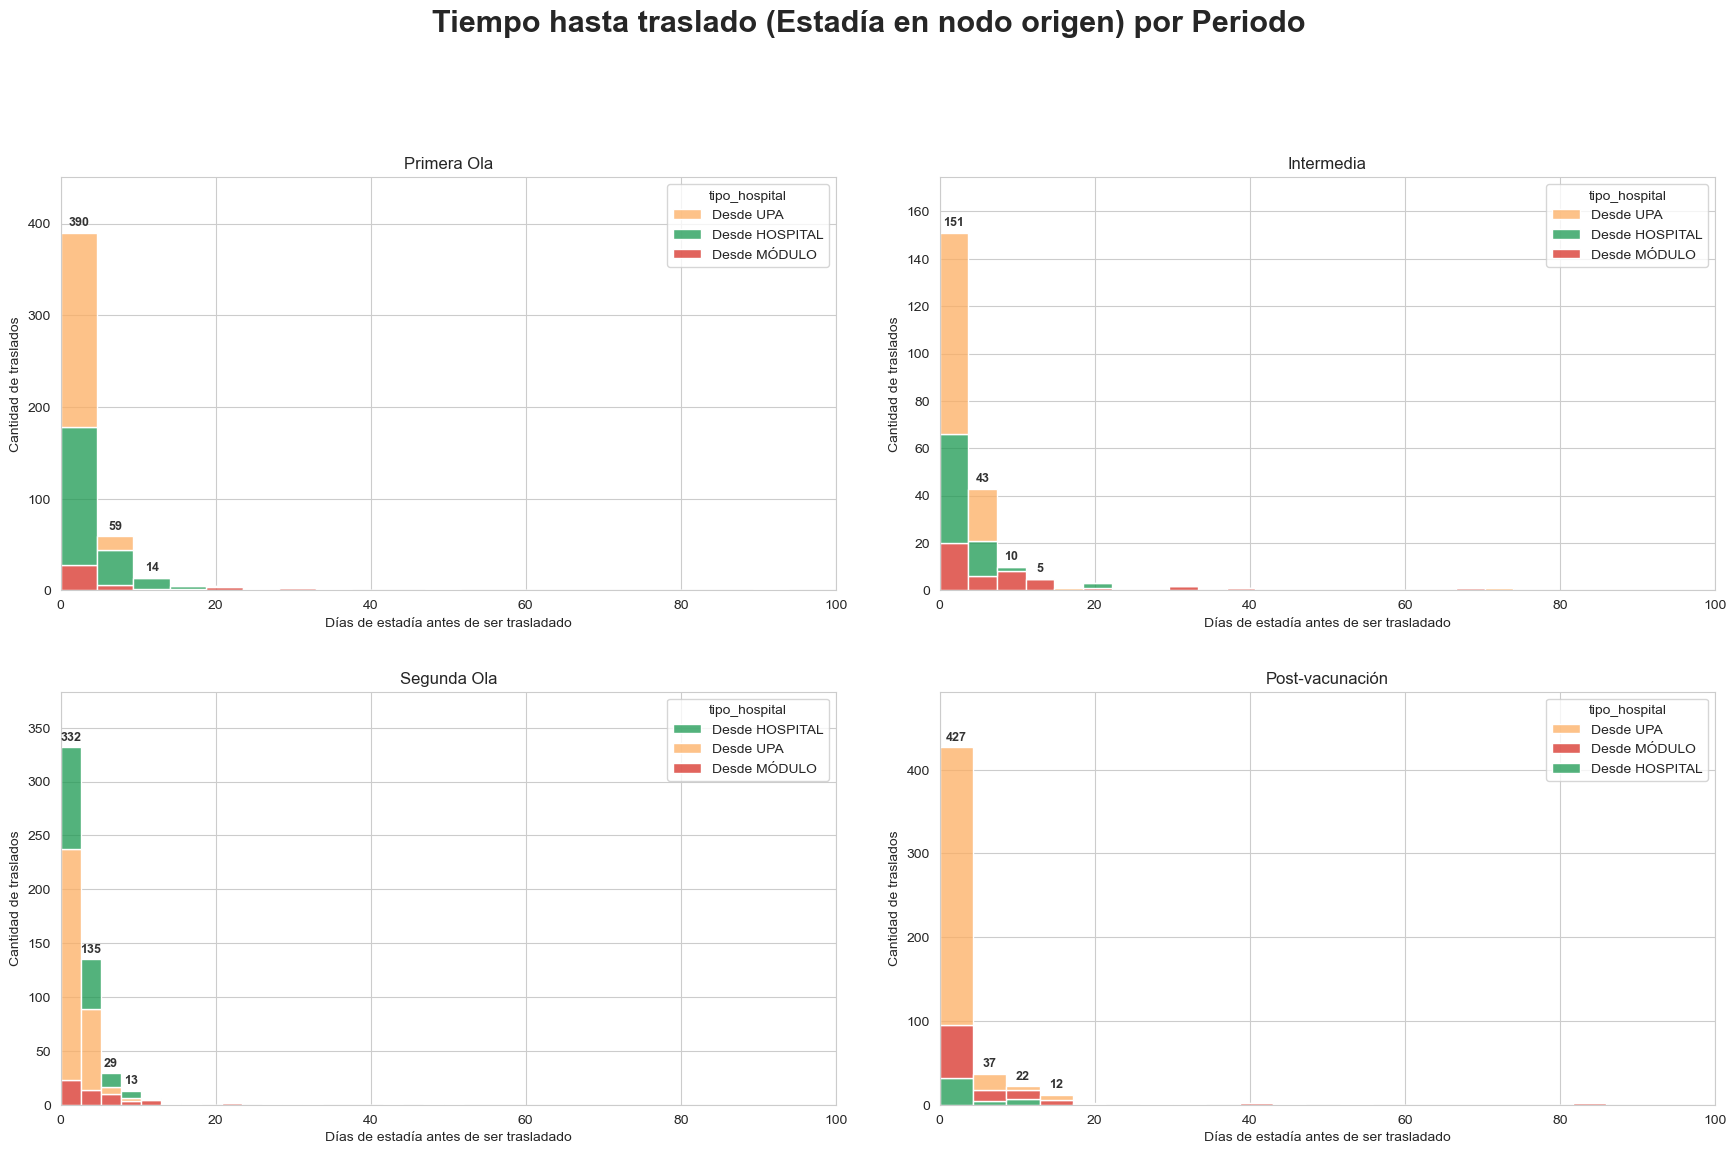

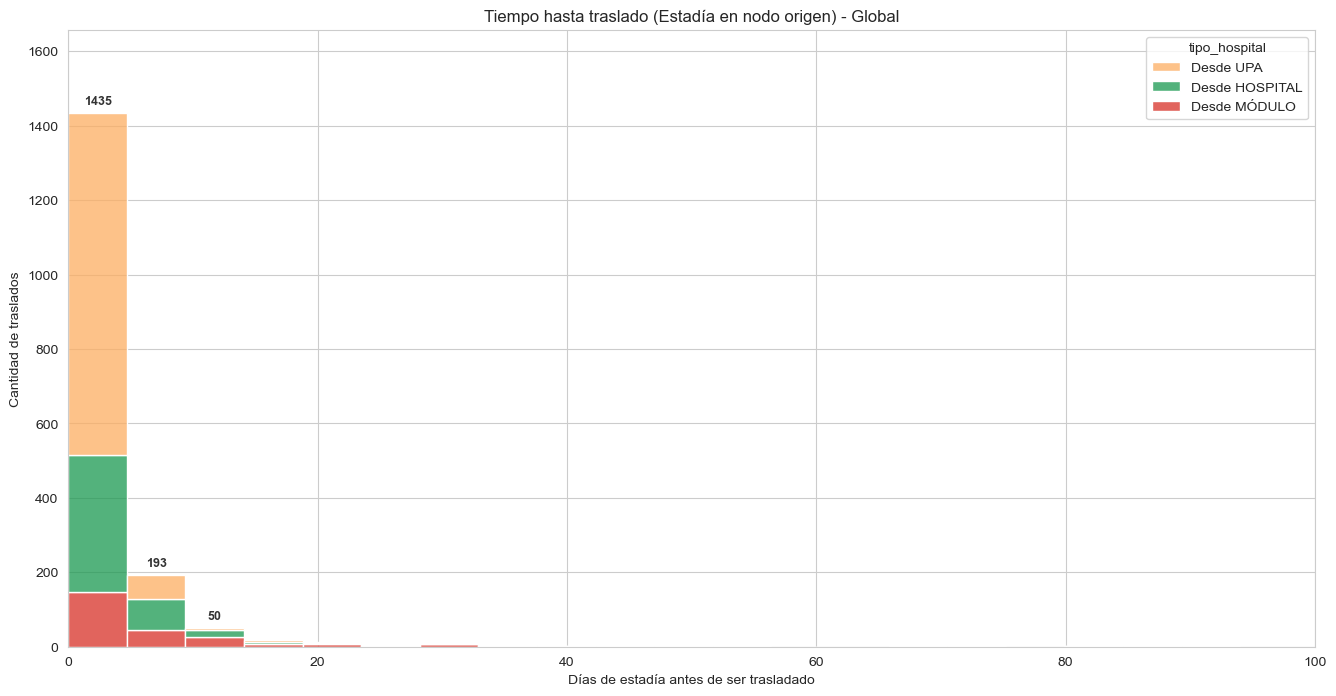

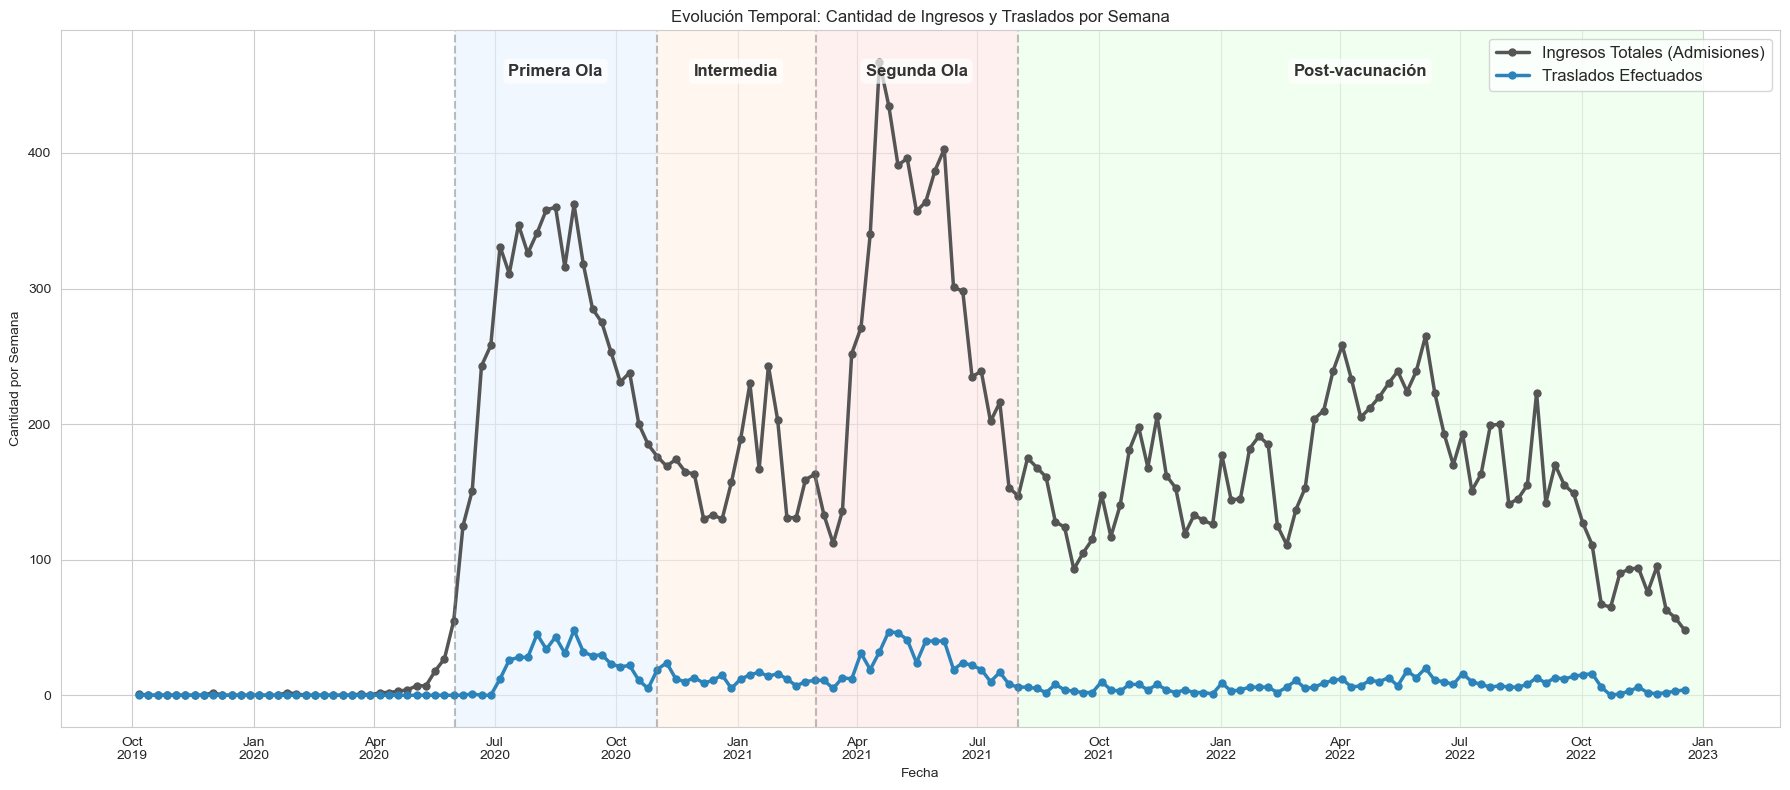

In [9]:
# 9. ANÁLISIS ESTADÍSTICO Y TEMPORAL (DRY)
# ==========================================
mask_validos_stats = (df_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & (df_traslados['hospital_destino'].isin(hospitales_conocidos)) & (df_traslados['hospital_ingreso'] != df_traslados['hospital_destino'])
df_traslados_stats = df_traslados[mask_validos_stats].copy()

# Funciones de Anotación Originales (Intactas)

# --- 9.1 Gráfico de Puntos Conectados (Ex Lollipop) ---
promedios_traslados = {} # REQ 5: Diccionario para guardar los promedios calculados

# Pasamos el diccionario como cuarto argumento
graficar_traslados_paciente(df_traslados_stats, pacientes, es_global=False, promedios_traslados=promedios_traslados)
graficar_traslados_paciente(df_traslados_stats, pacientes, es_global=True, promedios_traslados=promedios_traslados)

# Impresión de control para el REQ 5
print("-" * 50)
print("PROMEDIO DE TRASLADOS POR PACIENTE (INCLUYE 0s):")
for periodo, prom in promedios_traslados.items():
    print(f"{periodo}: {prom:.4f}")
print("-" * 50)


# --- 9.2 Tiempo en el Sistema Histograms ---
tiempo_trayectorias_todas = pacientes.groupby('paciente_id').agg(ingreso=('fecha_ingreso', 'min'), egreso=('fecha_egreso', 'max'))
tiempo_trayectorias_todas['dias_en_sistema'] = (tiempo_trayectorias_todas['egreso'] - tiempo_trayectorias_todas['ingreso']).dt.days
tiempo_trayectorias_todas = tiempo_trayectorias_todas[tiempo_trayectorias_todas['dias_en_sistema'] >= 0].copy()

df_trasladados = tiempo_trayectorias_todas[tiempo_trayectorias_todas.index.isin(set(df_traslados_stats['paciente_id']))]

# Calculamos el límite de ploteo global para que todos compartan el mismo eje X
limite_p99 = tiempo_trayectorias_todas['dias_en_sistema'].quantile(0.99)
max_plot = int(limite_p99) if not pd.isna(limite_p99) else int(tiempo_trayectorias_todas['dias_en_sistema'].max())
bins_5dias = np.arange(0, max_plot + 5, 5)


# Graficar la versión global
graficar_tiempo_sistema(tiempo_trayectorias_todas, df_trasladados, es_global=True)

# Graficar la versión por periodos
graficar_tiempo_sistema(tiempo_trayectorias_todas, df_trasladados, es_global=False)

# --- 9.3 Scatter de Traslados vs Tiempo (< 4) ---
df_cruce = pd.merge(tiempo_trayectorias_todas, df_traslados_stats.groupby('paciente_id').size().reset_index(name='cantidad_traslados'), on='paciente_id', how='inner')
df_plot = df_cruce[df_cruce['cantidad_traslados'] < 4].copy()
df_plot['dias_plot'] = df_plot['dias_en_sistema'].replace(0, 0.5)

fig3, ax3 = plt.subplots(figsize=(12, 8))
fig3.patch.set_facecolor('white')
sns.stripplot(data=df_plot, x='cantidad_traslados', y='dias_plot', color='#4c72b0', alpha=0.4, jitter=0.2, size=5, ax=ax3, zorder=1)
sns.pointplot(data=df_plot, x='cantidad_traslados', y='dias_plot', estimator=np.mean, errorbar='sd', color='#d62728', markers='D', capsize=0.1, err_kws={'linewidth': 2}, ax=ax3, zorder=3)

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:g}'.format(y)))
ax3.set(title="Relación entre Cantidad de Traslados y Días en el Sistema\n(Solo pacientes con 1 a 3 traslados)", xlabel="Cantidad de Traslados", ylabel="Días totales en el sistema (Escala Log)")
ax3.legend(handles=[mlines.Line2D([], [], color='#d62728', marker='D', markersize=8, label='Promedio ± Desvío Estándar')], loc='upper left', frameon=True, fontsize=12)
plt.tight_layout()
plt.show()

# --- 9.4 Tiempo hasta Traslado (Barras Apiladas) ---
df_movimientos = df_traslados_stats.copy()
df_movimientos['dias_antes_traslado'] = (df_movimientos['fecha_egreso'] - df_movimientos['fecha_ingreso']).dt.days
df_movimientos = df_movimientos[df_movimientos['dias_antes_traslado'] >= 0]
df_movimientos['tipo_hospital'] = df_movimientos['hospital_ingreso'].apply(clasificar_hospital) # Usamos la func auxiliar DRY

limite_p99_nodo = df_movimientos['dias_antes_traslado'].quantile(0.99) if not df_movimientos.empty else 30
max_plot_nodo = int(limite_p99_nodo) if not pd.isna(limite_p99_nodo) else 30
bins_mov_5 = np.arange(0, max_plot_nodo + 5, 5)


graficar_tiempo_traslado(df_movimientos, es_global=False)
graficar_tiempo_traslado(df_movimientos, es_global=True)

# --- 9.5 Evolución Temporal ---
fig4, ax4 = plt.subplots(figsize=(18, 8))
fig4.patch.set_facecolor('white')

df_ts = pd.concat([
    pacientes.set_index('fecha_ingreso').resample('W').size().rename('Ingresos Totales'),
    df_traslados_stats.set_index('fecha_egreso').resample('W').size().rename('Traslados')
], axis=1).fillna(0)

ax4.plot(df_ts.index, df_ts['Ingresos Totales'], label='Ingresos Totales (Admisiones)', color='#555555', linewidth=2.5, marker='o', markersize=5)
ax4.plot(df_ts.index, df_ts['Traslados'], label='Traslados Efectuados', color='#2b83ba', linewidth=2.5, marker='o', markersize=5)

colores_fondo = ['#e6f2ff', '#fff0e6', '#ffe6e6', '#e6ffe6'] 
for i, (titulo, inicio, fin) in enumerate(PERIODOS):
    f_ini, f_fin = pd.to_datetime(inicio), pd.to_datetime(fin)
    ax4.axvspan(f_ini, f_fin, color=colores_fondo[i % len(colores_fondo)], alpha=0.6)
    ax4.axvline(f_ini, color='gray', linestyle='--', alpha=0.5)
    ax4.text(f_ini + (f_fin - f_ini)/2, ax4.get_ylim()[1]*0.95, titulo, ha='center', va='top', fontsize=12, fontweight='bold', color='#333333', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

ax4.set(title="Evolución Temporal: Cantidad de Ingresos y Traslados por Semana", xlabel="Fecha", ylabel="Cantidad por Semana")
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax4.legend(loc='upper right', fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# CONSULTAS, FILTROS, RESULTADOS Y EXPORTACIÓN
# ==========================================

# ---------------------------------------------------------
# 1. ACCESO A LOS DATAFRAMES PRINCIPALES
# ---------------------------------------------------------
df_pacientes_final = pacientes.copy()        # 1. DF normal (historial completo)
df_eventos_traslados = df_traslados.copy()   # 2. DF de traslados (solo los eventos puente)
df_trayectorias_final = df_trayectorias_final.copy()  # 3. DF de trayectorias (1 fila por persona)

# ---------------------------------------------------------
# 2. PARÁMETROS PARA LOS CÁLCULOS
# ---------------------------------------------------------
# Definimos un periodo, un hospital y un ID de interés para hacer las pruebas
fecha_inicio_filtro = '2020-06-01'
fecha_fin_filtro = '2022-12-31'
hospital_interes = 'Evita Pueblo'
id_buscado = 'WN04' # Reemplazar por el ID real

# ---------------------------------------------------------
# 3. FILTRADO DE PACIENTES Y EVENTOS
# ---------------------------------------------------------
# Búsqueda de pacientes críticos (en el DF base y en trayectorias)
# pacientes_criticos_base = df_pacientes_final[df_pacientes_final['tipo_ingreso'].str.contains('crític', case=False, na=False)]
# trayectorias_criticas = df_trayectorias_final[df_trayectorias_final['tipo_final_txt'].str.contains('crític', case=False, na=False)]


# Búsquedas específicas y de traslados lentos
traslados_lentos = df_eventos_traslados[df_eventos_traslados['dias_traslado'] > 2]
historia_paciente = df_pacientes_final[df_pacientes_final['paciente_id'] == id_buscado]

# ---------------------------------------------------------
# 4. CONTADORES (INGRESOS Y TRASLADOS EN EL PERIODO)
# ---------------------------------------------------------
# A. Contar Ingresos (Todos vs Un Hospital)
mask_periodo_ingresos = (df_pacientes_final['fecha_ingreso'] >= fecha_inicio_filtro) & \
                        (df_pacientes_final['fecha_ingreso'] <= fecha_fin_filtro)

ingresos_totales_periodo = df_pacientes_final[mask_periodo_ingresos].shape[0]

mask_hospital_ingreso = mask_periodo_ingresos & (df_pacientes_final['hospital_origen'] == hospital_interes)
ingresos_hospital_periodo = df_pacientes_final[mask_hospital_ingreso].shape[0]

# B. Contar Traslados Efectuados (Enviados)
mask_traslados_enviados = (df_eventos_traslados['fecha_egreso'] >= fecha_inicio_filtro) & \
                          (df_eventos_traslados['fecha_egreso'] <= fecha_fin_filtro) & \
                          (df_eventos_traslados['hospital_ingreso'] == hospital_interes)

traslados_enviados_count = df_eventos_traslados[mask_traslados_enviados].shape[0]

# C. Contar Traslados Recibidos
mask_traslados_recibidos = (df_eventos_traslados['fecha_egreso'] >= fecha_inicio_filtro) & \
                           (df_eventos_traslados['fecha_egreso'] <= fecha_fin_filtro) & \
                           (df_eventos_traslados['hospital_destino'] == hospital_interes)

traslados_recibidos_count = df_eventos_traslados[mask_traslados_recibidos].shape[0]

# D. Contar cantidad de pacientes únicos
pacientes_unicos_trasladados = len(df_trayectorias_final)
pacientes_unicos_absolutos = df_pacientes_final['paciente_id'].nunique()

# ---------------------------------------------------------
# 5. IMPRESIÓN DE RESULTADOS
# ---------------------------------------------------------
print("="*50)
print(f"RESULTADOS PARA EL PERIODO: {fecha_inicio_filtro} al {fecha_fin_filtro}")
print("="*50)
print(f"Hospital analizado: {hospital_interes}\n")
print(f"INGRESOS:\n  - Totales en la red: {ingresos_totales_periodo}\n  - Solo en {hospital_interes}: {ingresos_hospital_periodo}\n")
print(f"TRASLADOS DE {hospital_interes}:\n  - Efectuados (Enviados a otros): {traslados_enviados_count}\n  - Recibidos (Desde otros): {traslados_recibidos_count}\n")
print(f"MÉTRICAS GLOBALES DE PACIENTES:\n  - Total de personas registradas (históricas): {pacientes_unicos_absolutos}\n  - Total de personas con al menos 1 traslado: {pacientes_unicos_trasladados}")
print("="*50)

# ---------------------------------------------------------
# 6. EXPORTACIÓN A EXCEL
# ---------------------------------------------------------
ruta_exportacion = "../data/revision_dfs.xlsx"
with pd.ExcelWriter(ruta_exportacion, engine='xlsxwriter') as writer:
    df_pacientes_final.to_excel(writer, sheet_name='1_Pacientes_Base', index=False)
    df_eventos_traslados.to_excel(writer, sheet_name='2_Eventos_Traslados', index=False)
    df_trayectorias_final.to_excel(writer, sheet_name='3_Trayectorias', index=False)
    # NOTA: Asegurate de que la variable 'tabla_resumen' exista y haya sido 
    # generada en pasos anteriores, si no esta línea te tirará error:
    tabla_resumen.to_excel(writer, sheet_name='4_Tabla_Resumen', index=True)

RESULTADOS PARA EL PERIODO: 2020-06-01 al 2022-12-31
Hospital analizado: Evita Pueblo

INGRESOS:
  - Totales en la red: 26397
  - Solo en Evita Pueblo: 1510

TRASLADOS DE Evita Pueblo:
  - Efectuados (Enviados a otros): 3
  - Recibidos (Desde otros): 0

MÉTRICAS GLOBALES DE PACIENTES:
  - Total de personas registradas (históricas): 27295
  - Total de personas con al menos 1 traslado: 1593
